In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import callbacks
from tensorflow.keras import optimizers

from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
DATASET_PATH = Path(r"E:\Nit RKL projects\SkinDisease-Detection-System\SkinDisease_Prepared")

TRAIN_DIR = DATASET_PATH / "train"
VAL_DIR   = DATASET_PATH / "validation"
TEST_DIR  = DATASET_PATH / "test"

print("Train :", TRAIN_DIR)
print("Validation :", VAL_DIR)
print("Test :", TEST_DIR)

Train : E:\Nit RKL projects\SkinDisease-Detection-System\SkinDisease_Prepared\train
Validation : E:\Nit RKL projects\SkinDisease-Detection-System\SkinDisease_Prepared\validation
Test : E:\Nit RKL projects\SkinDisease-Detection-System\SkinDisease_Prepared\test


In [6]:
# Verify Dataset
print("="*60)

for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    print(f"\n{split.name.upper()}")

    total = 0

    for cls in sorted(os.listdir(split)):
        class_path = split / cls

        if class_path.is_dir():

            count = len(list(class_path.glob("*.*")))

            total += count

            print(f"{cls:<20} : {count}")

    print(f"Total Images : {total}")

print("="*60)


TRAIN
Benign_Tumors        : 930
Skin_Cancer          : 597
Unknown_Normal       : 1404
Vascular_Tumors      : 462
Total Images : 3393

VALIDATION
Benign_Tumors        : 163
Skin_Cancer          : 96
Unknown_Normal       : 247
Vascular_Tumors      : 81
Total Images : 587

TEST
Benign_Tumors        : 121
Skin_Cancer          : 77
Unknown_Normal       : 189
Vascular_Tumors      : 60
Total Images : 447


In [8]:
# Hyperparameters
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

BATCH_SIZE = 32

NUM_CLASSES = 4

EPOCHS = 30

AUTOTUNE = tf.data.AUTOTUNE

print("=" * 60)
print("Hyperparameters")
print("=" * 60)

print(f"Image Size : {IMAGE_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Epochs     : {EPOCHS}")
print(f"Classes    : {NUM_CLASSES}")

Hyperparameters
Image Size : (224, 224)
Batch Size : 32
Epochs     : 30
Classes    : 4


In [10]:
# Load Dataset
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3393 files belonging to 4 classes.
Found 587 files belonging to 4 classes.
Found 447 files belonging to 4 classes.


In [11]:

#Print Class Names
class_names = train_ds.class_names

print("=" * 60)
print("Classes")
print("=" * 60)

for i, name in enumerate(class_names):
    print(f"{i} -> {name}")

Classes
0 -> Benign_Tumors
1 -> Skin_Cancer
2 -> Unknown_Normal
3 -> Vascular_Tumors


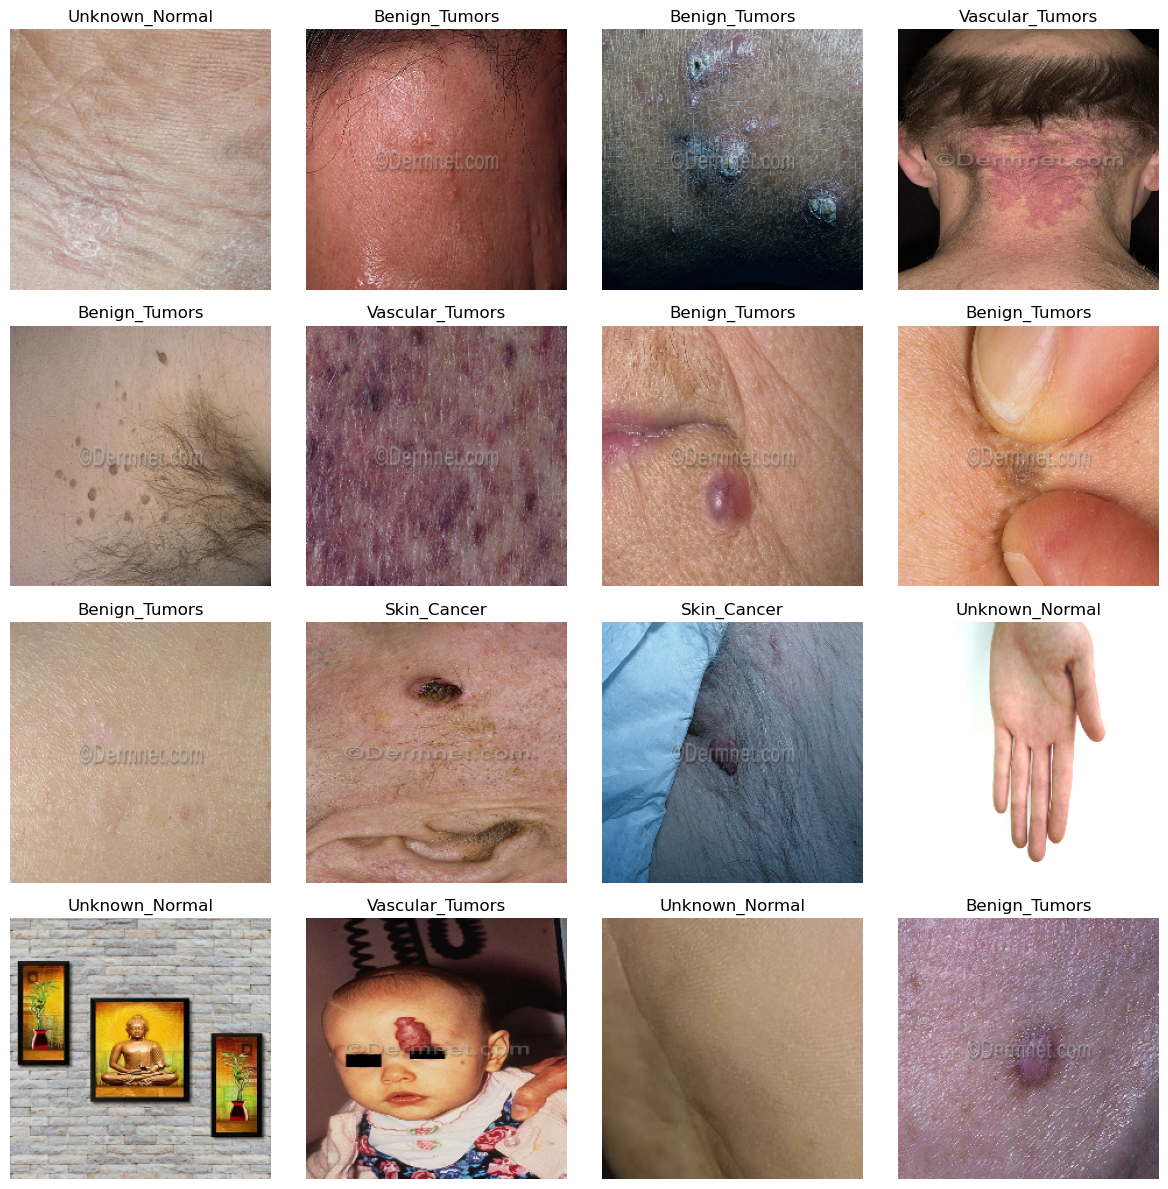

In [12]:

# visualize the data 
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(16):

        plt.subplot(4,4,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

# Data Augmentation 

In [13]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.10),

    layers.RandomZoom(0.10),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    layers.RandomContrast(0.10),

], name="Data_Augmentation")

print(data_augmentation)

<Sequential name=Data_Augmentation, built=False>


In [14]:
# Normalization Layer
normalization = layers.Rescaling(1.0 / 255)

print("Normalization layer created.")

Normalization layer created.


In [15]:
# Apply Preprocessing

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda images, labels: (
        normalization(
            data_augmentation(images, training=True)
        ),
        labels
    ),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda images, labels: (
        normalization(images),
        labels
    ),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda images, labels: (
        normalization(images),
        labels
    ),
    num_parallel_calls=AUTOTUNE
)

In [16]:
# Performance Optimization
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset pipeline is ready.")

Dataset pipeline is ready.


In [17]:
# Compute Class Weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Collect all labels from the training dataset
train_labels = []

for _, labels in train_ds.unbatch():
    train_labels.append(int(labels.numpy()))

train_labels = np.array(train_labels)

# Compute class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight = {
    i: weight
    for i, weight in enumerate(weights)
}

print("=" * 60)
print("Class Weights")
print("=" * 60)

for i, w in class_weight.items():
    print(f"{class_names[i]:20} : {w:.3f}")

Class Weights
Benign_Tumors        : 0.912
Skin_Cancer          : 1.421
Unknown_Normal       : 0.604
Vascular_Tumors      : 1.836


In [19]:
# Build EfficientNetB0 Model
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Model
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.20)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="SkinDisease_EfficientNetB0"
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step


Model: "SkinDisease_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [20]:

model.summary()

Model: "SkinDisease_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
# Compile Model

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ]

)

print("Model compiled successfully!")

Model compiled successfully!


In [22]:
# Callbacks

early_stop = callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

checkpoint = callbacks.ModelCheckpoint(

    "best_skin_disease_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [23]:
# Train Model
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    class_weight=class_weight,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/30
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.2459 - loss: 1.4265
Epoch 1: val_accuracy improved from None to 0.16354, saving model to best_skin_disease_model.keras

Epoch 1: finished saving model to best_skin_disease_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.2458 - loss: 1.4266 - val_accuracy: 0.1635 - val_loss: 1.4217 - learning_rate: 0.0010
Epoch 2/30
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.2137 - loss: 1.3996
Epoch 2: val_accuracy did not improve from 0.16354
107/107 ━━━━━━━━━━━━━━━━━━━━ 51s 459ms/step - accuracy: 0.2137 - loss: 1.3995 - val_accuracy: 0.1380 - val_loss: 1.3896 - learning_rate: 0.0010
Epoch 3/30
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.2771 - loss: 1.3901
Epoch 3: val_accuracy did not improve from 0.16354
107/107 ━━━━━━━━━━━━━━━━━━━━ 57s 518ms/step - accuracy: 0.2770 - loss: 1.3900 - val_accuracy: 0.1635 - val_loss: 1.3923 - learning_rate: 0.0010
Epoch 4/30
106/107 ━━━━━━━━━━━━━━━━━━━━ 

In [24]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 3393 files belonging to 4 classes.
Found 587 files belonging to 4 classes.
Found 447 files belonging to 4 classes.


In [25]:
# builde the model properly
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

# EfficientNet preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [26]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [27]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5

)

Epoch 1/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 63s 496ms/step - accuracy: 0.4633 - loss: 1.4829 - val_accuracy: 0.6303 - val_loss: 0.9334
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 469ms/step - accuracy: 0.6522 - loss: 0.8892 - val_accuracy: 0.6951 - val_loss: 0.7617
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 51s 478ms/step - accuracy: 0.7038 - loss: 0.7456 - val_accuracy: 0.6968 - val_loss: 0.7567
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 469ms/step - accuracy: 0.7218 - loss: 0.6936 - val_accuracy: 0.6985 - val_loss: 0.7632
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 469ms/step - accuracy: 0.7486 - loss: 0.6381 - val_accuracy: 0.7104 - val_loss: 0.7535


In [28]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "best_skin_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.7529 - loss: 0.6058
Epoch 1: val_accuracy improved from None to 0.71210, saving model to best_skin_model.keras

Epoch 1: finished saving model to best_skin_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 67s 631ms/step - accuracy: 0.7527 - loss: 0.6061 - val_accuracy: 0.7121 - val_loss: 0.7434 - learning_rate: 1.0000e-04
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.7703 - loss: 0.5707
Epoch 2: val_accuracy improved from 0.71210 to 0.71721, saving model to best_skin_model.keras

Epoch 2: finished saving model to best_skin_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 105s 656ms/step - accuracy: 0.7704 - loss: 0.5709 - val_accuracy: 0.7172 - val_loss: 0.7515 - learning_rate: 1.0000e-04
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.7730 - loss: 0.5508
Epoch 3: val_accuracy improved from 0.71721 to 0.72572, saving model to best_skin_model.keras

Epoch 3: finished saving model to best_skin_m

In [30]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy : {test_acc:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8255 - loss: 0.4230
Test Accuracy : 0.8255


In [31]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print("=" * 60)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 365ms/step - accuracy: 0.8255 - loss: 0.4230
Test Loss     : 0.4230
Test Accuracy : 0.8255


In [32]:
predictions = model.predict(test_ds)

y_pred = np.argmax(predictions, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 562ms/step


In [33]:
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

In [34]:
print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

Classification Report
                 precision    recall  f1-score   support

  Benign_Tumors     0.7273    0.8595    0.7879       121
    Skin_Cancer     0.7313    0.6364    0.6806        77
 Unknown_Normal     0.9895    1.0000    0.9947       189
Vascular_Tumors     0.5870    0.4500    0.5094        60

       accuracy                         0.8255       447
      macro avg     0.7588    0.7365    0.7432       447
   weighted avg     0.8200    0.8255    0.8195       447



<Figure size 800x800 with 0 Axes>

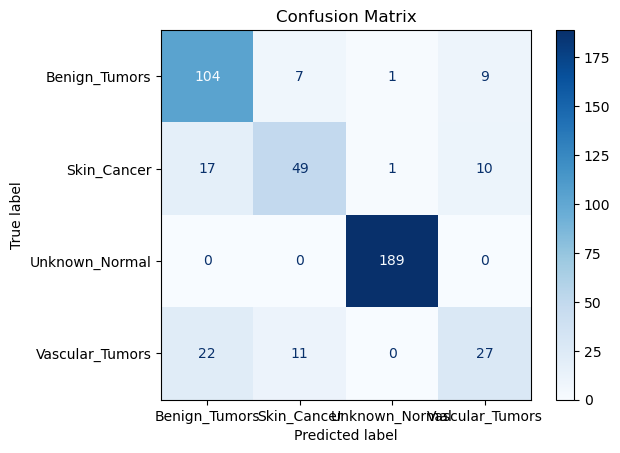

In [35]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8,8))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.show()

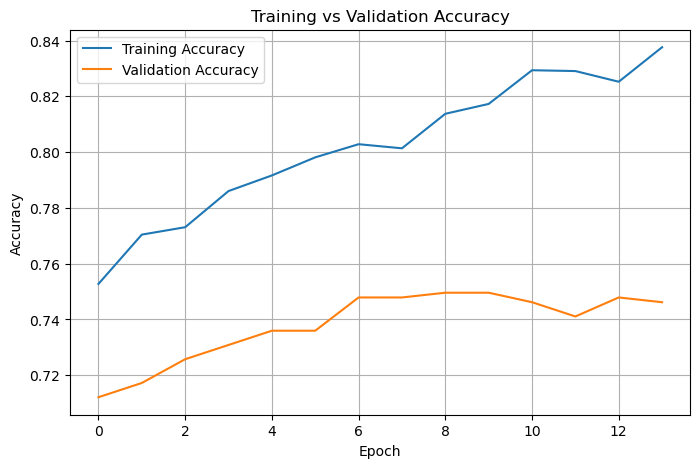

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

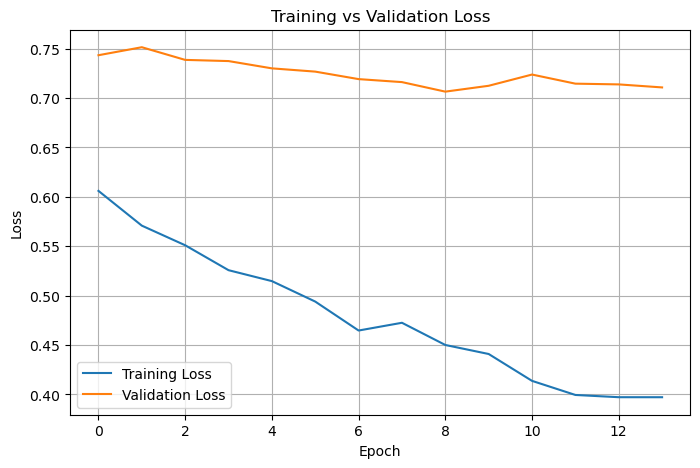

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [39]:
base_model.trainable = True

# Freeze all except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable layers:")

for layer in base_model.layers[-30:]:
    print(layer.name, layer.trainable)

Trainable layers:
block6d_expand_bn True
block6d_expand_activation True
block6d_dwconv True
block6d_bn True
block6d_activation True
block6d_se_squeeze True
block6d_se_reshape True
block6d_se_reduce True
block6d_se_expand True
block6d_se_excite True
block6d_project_conv True
block6d_project_bn True
block6d_drop True
block6d_add True
block7a_expand_conv True
block7a_expand_bn True
block7a_expand_activation True
block7a_dwconv True
block7a_bn True
block7a_activation True
block7a_se_squeeze True
block7a_se_reshape True
block7a_se_reduce True
block7a_se_expand True
block7a_se_excite True
block7a_project_conv True
block7a_project_bn True
top_conv True
top_bn True
top_activation True


In [40]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [41]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_skin_finetune.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [42]:
history_fine = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.7660 - loss: 0.6158
Epoch 1: val_accuracy improved from None to 0.72402, saving model to best_skin_finetune.keras

Epoch 1: finished saving model to best_skin_finetune.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7660 - loss: 0.6158 - val_accuracy: 0.7240 - val_loss: 0.7803 - learning_rate: 1.0000e-05
Epoch 2/15
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.7518 - loss: 0.6243
Epoch 2: val_accuracy did not improve from 0.72402
107/107 ━━━━━━━━━━━━━━━━━━━━ 56s 521ms/step - accuracy: 0.7515 - loss: 0.6245 - val_accuracy: 0.7155 - val_loss: 0.8024 - learning_rate: 1.0000e-05
Epoch 3/15
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.7706 - loss: 0.5843
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 3: val_accuracy did not improve from 0.72402
107/107 ━━━━━━━━━━━━━━━━━━━━ 57s 536ms/step - accuracy: 0.7704 - loss: 0.5846 - val_accuracy: 0.7189 - val_l

In [44]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),
], name="Data_Augmentation")

print("Data augmentation created successfully!")

Data augmentation created successfully!


In [45]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_aug = train_ds.map(

    lambda x, y: (
        data_augmentation(x, training=True),
        y
    ),

    num_parallel_calls=AUTOTUNE

)

train_ds_aug = train_ds_aug.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

In [46]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

In [47]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [48]:
history_aug = model.fit(

    train_ds_aug,

    validation_data=val_ds,

    epochs=20,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.7253 - loss: 0.7112
Epoch 1: val_accuracy improved from 0.72402 to 0.74787, saving model to best_skin_finetune.keras

Epoch 1: finished saving model to best_skin_finetune.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.7253 - loss: 0.7112 - val_accuracy: 0.7479 - val_loss: 0.7724 - learning_rate: 1.0000e-04
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.7489 - loss: 0.6244
Epoch 2: val_accuracy did not improve from 0.74787
107/107 ━━━━━━━━━━━━━━━━━━━━ 60s 553ms/step - accuracy: 0.7489 - loss: 0.6244 - val_accuracy: 0.7479 - val_loss: 0.7786 - learning_rate: 1.0000e-04
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7748 - loss: 0.5602
Epoch 3: val_accuracy improved from 0.74787 to 0.75128, saving model to best_skin_finetune.keras

Epoch 3: finished saving model to best_skin_finetune.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 107s 991ms/step - accuracy: 0.7748 - loss: 0.560

In [49]:
# Create Results Folder
from pathlib import Path

RESULTS_DIR = Path("Results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Results folder created.")

Results folder created.


In [50]:
# Save Training History
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.index += 1
history_df.index.name = "Epoch"

history_df.to_csv(
    RESULTS_DIR / "training_history.csv",
    index=True
)

print(history_df.head())

       accuracy      loss  val_accuracy  val_loss  learning_rate
Epoch                                                           
1      0.752726  0.606075      0.712095  0.743438         0.0001
2      0.770410  0.570879      0.717206  0.751538         0.0001
3      0.773062  0.551011      0.725724  0.738712         0.0001
4      0.786030  0.525769      0.730835  0.737511         0.0001
5      0.791630  0.514702      0.735945  0.730136         0.0001


In [51]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["EfficientNetB0"],
    "Dataset": ["Skin Disease (4 Classes)"],
    "Train Images": [3393],
    "Validation Images": [587],
    "Test Images": [447],
    "Image Size": ["224x224"],
    "Epochs": [14],
    "Batch Size": [32],
    "Optimizer": ["Adam"],
    "Learning Rate": [1e-4],
    "Transfer Learning": ["Yes"],
    "Fine Tuning": ["No (Frozen Backbone)"],
    "Train Accuracy": [83.76],
    "Validation Accuracy": [74.96],
    "Test Accuracy": [82.55],
    "Test Loss": [0.4230],
    "Precision": [0.8200],
    "Recall": [0.8255],
    "Weighted F1 Score": [0.8195],
    "Macro F1 Score": [0.7432],
    "Notes": ["Baseline EfficientNetB0"]
})

results.to_csv("model_results.csv", index=False)

print(results)

            Model                   Dataset  Train Images  Validation Images  \
0  EfficientNetB0  Skin Disease (4 Classes)          3393                587   

   Test Images Image Size  Epochs  Batch Size Optimizer  Learning Rate  ...  \
0          447    224x224      14          32      Adam         0.0001  ...   

            Fine Tuning Train Accuracy  Validation Accuracy  Test Accuracy  \
0  No (Frozen Backbone)          83.76                74.96          82.55   

   Test Loss  Precision  Recall  Weighted F1 Score  Macro F1 Score  \
0      0.423       0.82  0.8255             0.8195          0.7432   

                     Notes  
0  Baseline EfficientNetB0  

[1 rows x 21 columns]


In [52]:
class_results = pd.DataFrame({

    "Class":[
        "Benign_Tumors",
        "Skin_Cancer",
        "Unknown_Normal",
        "Vascular_Tumors"
    ],

    "Precision":[
        0.7273,
        0.7313,
        0.9895,
        0.5870
    ],

    "Recall":[
        0.8595,
        0.6364,
        1.0000,
        0.4500
    ],

    "F1 Score":[
        0.7879,
        0.6806,
        0.9947,
        0.5094
    ],

    "Support":[
        121,
        77,
        189,
        60
    ]
})

class_results.to_csv("class_performance.csv", index=False)

print(class_results)

             Class  Precision  Recall  F1 Score  Support
0    Benign_Tumors     0.7273  0.8595    0.7879      121
1      Skin_Cancer     0.7313  0.6364    0.6806       77
2   Unknown_Normal     0.9895  1.0000    0.9947      189
3  Vascular_Tumors     0.5870  0.4500    0.5094       60


In [53]:
experiment = pd.DataFrame({

    "Experiment ID":[1],

    "Model":[
        "EfficientNetB0"
    ],

    "Experiment":[
        "Baseline Transfer Learning"
    ],

    "Image Size":[224],

    "Batch Size":[32],

    "Epochs":[14],

    "Learning Rate":[1e-4],

    "Frozen Layers":[
        "All"
    ],

    "Augmentation":[
        "No"
    ],

    "Class Weight":[
        "No"
    ],

    "Validation Accuracy":[74.96],

    "Test Accuracy":[82.55],

    "Remarks":[
        "Best baseline model"
    ]

})

experiment.to_csv("experiment_log.csv", index=False)

print(experiment)

   Experiment ID           Model                  Experiment  Image Size  \
0              1  EfficientNetB0  Baseline Transfer Learning         224   

   Batch Size  Epochs  Learning Rate Frozen Layers Augmentation Class Weight  \
0          32      14         0.0001           All           No           No   

   Validation Accuracy  Test Accuracy              Remarks  
0                74.96          82.55  Best baseline model  
